# SASRec-et előzetesen zárt téren (tartalom alapú) tanítottam jelöltgenerálásra

# Mel

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm.auto import tqdm
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
AE_MATRIX_PATH  = "../Models/ae_vectors_closed_world_mel_only.npy"
VAL_DATA_PATH   = "../Models/val_pids_ae.npy"
WEIGHTS_PATH    = "../Models/best_sasrec_bpr_ae_mel_only.weights.h5"
H5_PATH         = "../Dataset/spotify_dataset_compressed.h5"
OUTPUT_PARQUET  = "../Models/xgb_train_ae_mel_only.parquet"

MAX_LEN    = 50
D_MODEL    = 256
BATCH_SIZE = 256
TOP_K      = 500

# ==========================================
# 2. EMBEDDINGEK ÉS VOCAB BETÖLTÉSE
# ==========================================
print("📂 AE vektorok betöltése...")
ae_weights = np.load(AE_MATRIX_PATH).astype('float32')

# Padding sor hozzáadása (0-s ID = csupa nulla vektor) — ugyanaz mint tanításnál!
padding_row = np.zeros((1, D_MODEL), dtype='float32')
embedding_matrix = np.vstack([padding_row, ae_weights])  # (vocab_size, 256)
vocab_size = embedding_matrix.shape[0]
print(f"✅ Embedding mátrix: {embedding_matrix.shape} | vocab_size: {vocab_size}")

# Az AE encoder L2-normált vektorokat ad ki → dot product = koszinusz hasonlóság.
# Normalizáljuk a kész mátrixot is FAISS-hoz.
embeddings_norm = embedding_matrix.copy()
faiss.normalize_L2(embeddings_norm)

# ==========================================
# 3. HDF5 METAADATOK BETÖLTÉSE (TARTALOM ALAPÚ)
# ==========================================
print("🧮 HDF5 tartalom metaadatok betöltése...")

track_global_entropy    = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)

with h5py.File(H5_PATH, "r") as hf:
    # A zárt világ mapping: HDF5 index + 1 = SASRec ID (pontosan ahogy a mapping szkript csinálja)
    track_uris_hdf5     = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data  = hf["features/markov_entropy_local"][:]

    for hdf5_idx in tqdm(range(len(track_uris_hdf5)), desc="Entropy mapping"):
        sasrec_id = hdf5_idx + 1  # ID = index + 1 (padding miatt)
        if sasrec_id < vocab_size:
            track_global_entropy[sasrec_id]    = entropy_global_data[hdf5_idx][0]
            track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])

print(f"✅ Entropy feltöltve: {(~np.isnan(track_global_entropy)).sum():,} / {vocab_size:,} dal")

# ==========================================
# 4. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec inferencia modell felépítése...")

def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="ae_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL // 8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embedding_matrix)
inference_model.load_weights(WEIGHTS_PATH)
print("✅ Súlyok betöltve!")

# ==========================================
# 5. FAISS INDEX FELÉPÍTÉSE A FINOMHANGOLT EMBEDDINGEKBŐL
# ==========================================
print("🔍 FAISS Index felépítése a tanult embeddingekből...")
learned_embeddings = inference_model.get_layer("ae_embedding").get_weights()[0].astype('float32')
faiss_embeddings   = learned_embeddings.copy()
faiss.normalize_L2(faiss_embeddings)

index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)
print(f"✅ FAISS index: {index.ntotal:,} vektor")

# A normalizált learned embeddinget fogjuk feature számításhoz is használni
# (konzisztens a FAISS kereséssel)
learned_embeddings_norm = faiss_embeddings

# ==========================================
# 6. PLAYLIST-SZINTŰ KONTEXTUS FEATURE-ÖK SZÁMÍTÁSA
#    (Tartalom alapú — nem tartalmaz kollaboratív jelet)
# ==========================================
# Feature-ök magyarázata:
#   Sim_to_Last       — koszinusz hasonlóság az utolsó hallgatott dalhoz
#   Sim_to_Mean       — hasonlóság a lista átlagvektorához
#   Sim_to_Recent_3   — hasonlóság az utolsó 3 dalhoz átlagban
#   Max_Sim_in_Context — a legközelebbi kontextus-dal hasonlósága (top-1)
#   Global_Entropy    — Markov-entrópia (átmeneti sokszínűség a dalban)
#   Max_Local_Entropy — max lokális Markov-entrópia
#   Entropy_Diff      — |jelölt entrópiája − lista átlag entrópiája|
#   Local_Entropy_Diff — max lokális entrópia különbség
#   Playlist_Entropy_Mean — a kontextus dalainak átlag entrópiája
#   Playlist_Local_Entropy_Mean — kontextus max lokális entrópia átlaga
#   SASRec_Score      — dot product a predikált vektorral (FAISS)
#   SASRec_Rank       — sorrendi pozíció a FAISS listában

# ==========================================
# 7. KÖTEGELT TÁBLÁZATGENERÁLÁS
# ==========================================
print("🚀 Táblázat generálása...")

val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
# Nulla paddingok eltávolítása (ha van)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)
print(f"📊 Validációs listák: {len(val_playlists):,}")

dataset_rows       = []
global_playlist_id = 0
writer             = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []

    for pl in batch_lists:
        if len(pl) < 2:
            continue
        targets.append(pl[-1])           # utolsó dal = target (leave-one-out)
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    if not batch_padded:
        continue

    # SASRec predikció
    pred_states        = inference_model.predict_on_batch(np.array(batch_padded))
    query_vectors      = pred_states[:, -1, :].astype('float32')  # utolsó pozíció
    faiss.normalize_L2(query_vectors)
    raw_scores, raw_indices = index.search(query_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(valid_contexts)):
        context      = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        context_set  = set(context)

        # --- Playlist-szintű feature-ök (minden jelöltre azonos) ---
        ctx_vecs = learned_embeddings_norm[list(context)]  # (N, D)

        last_vec          = learned_embeddings_norm[context[-1]]
        playlist_mean_vec = np.mean(ctx_vecs, axis=0)
        norm = np.linalg.norm(playlist_mean_vec)
        playlist_mean_vec = playlist_mean_vec / (norm + 1e-8)

        recent_3     = context[-3:]
        recent_3_vecs = learned_embeddings_norm[recent_3]  # (3, D)

        ctx_entropies       = [track_global_entropy[t] for t in context
                               if not np.isnan(track_global_entropy[t])]
        ctx_local_entropies = [track_max_local_entropy[t] for t in context
                               if not np.isnan(track_max_local_entropy[t])]

        playlist_entropy_mean       = float(np.mean(ctx_entropies))       if ctx_entropies       else 0.0
        playlist_local_entropy_mean = float(np.mean(ctx_local_entropies)) if ctx_local_entropies else 0.0

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context_set or cand_id == 0:
                continue
            if len(pos_samples) + len(neg_samples) >= TOP_K:
                break

            is_target  = 1 if cand_id == actual_target else 0
            cand_vec   = learned_embeddings_norm[cand_id]
            cand_g_ent = track_global_entropy[cand_id]
            cand_l_ent = track_max_local_entropy[cand_id]

            # --- Jelölt-szintű tartalom feature-ök ---
            sim_to_last     = float(np.dot(last_vec, cand_vec))
            sim_to_mean     = float(np.dot(playlist_mean_vec, cand_vec))
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))
            max_sim_in_ctx  = float(np.max(ctx_vecs @ cand_vec))

            entropy_diff       = float(abs(cand_g_ent - playlist_entropy_mean)) \
                                 if not np.isnan(cand_g_ent) else -1.0
            local_entropy_diff = float(abs(cand_l_ent - playlist_local_entropy_mean)) \
                                 if not np.isnan(cand_l_ent) else -1.0

            row = {
                # --- Azonosítók ---
                "Playlist_ID":    global_playlist_id,
                "Candidate_ID":   int(cand_id),
                "Playlist_Length": len(context),
                # --- SASRec rangsor ---
                "SASRec_Rank":  current_rank,
                "SASRec_Score": float(score),
                # --- Hasonlóság feature-ök (tartalom) ---
                "Sim_to_Last":       sim_to_last,
                "Sim_to_Mean":       sim_to_mean,
                "Sim_to_Recent_3":   sim_to_recent_3,
                "Max_Sim_in_Context": max_sim_in_ctx,
                # --- Entrópia feature-ök (tartalom) ---
                "Global_Entropy":           float(cand_g_ent) if not np.isnan(cand_g_ent) else -1.0,
                "Max_Local_Entropy":        float(cand_l_ent) if not np.isnan(cand_l_ent) else -1.0,
                "Playlist_Entropy_Mean":       playlist_entropy_mean,
                "Playlist_Local_Entropy_Mean": playlist_local_entropy_mean,
                "Entropy_Diff":       entropy_diff,
                "Local_Entropy_Diff": local_entropy_diff,
                # --- Cél ---
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH: 500k soronként írunk lemezre ---
    if len(dataset_rows) >= 500_000:
        df_chunk = pd.DataFrame(dataset_rows)
        table    = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 8. MARADÉK MENTÉS ÉS FÁJL LEZÁRÁS
# ==========================================
print("💾 Maradék sorok mentése...")
if dataset_rows:
    df_chunk = pd.DataFrame(dataset_rows)
    table    = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 9. SZŰRÉS: csak azok a listák maradnak, ahol a target megjelent a TOP_K-ban
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)

lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered    = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)

filtered_path  = OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet')
df_filtered.to_parquet(filtered_path, index=False)

print(f"\n🎉 KÉSZ!")
print(f"   Összes sor:        {len(df):,}")
print(f"   Szűrt sor:         {len(df_filtered):,}")
print(f"   Listák targettel:  {len(lists_with_pos):,} / {global_playlist_id:,}")
print(f"   Pozitív arány:     {df_filtered['Label'].mean():.4f}")
print(f"\n   Feature-ök: {[c for c in df_filtered.columns if c not in ['Playlist_ID','Candidate_ID','Label']]}")

del df, df_filtered
gc.collect()

📂 AE vektorok betöltése...
✅ Embedding mátrix: (27053, 256) | vocab_size: 27053
🧮 HDF5 tartalom metaadatok betöltése...


Entropy mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

✅ Entropy feltöltve: 27,052 / 27,053 dal
🏗️ SASRec inferencia modell felépítése...
✅ Súlyok betöltve!
🔍 FAISS Index felépítése a tanult embeddingekből...
✅ FAISS index: 27,053 vektor
🚀 Táblázat generálása...
📊 Validációs listák: 88,315


SASRec predikciók:   0%|          | 0/345 [00:00<?, ?it/s]

💾 Maradék sorok mentése...
🧹 Pozitív nélküli listák szűrése...

🎉 KÉSZ!
   Összes sor:        43,993,519
   Szűrt sor:         27,745,946
   Listák targettel:  55,725 / 88,315
   Pozitív arány:     0.0020

   Feature-ök: ['Playlist_Length', 'SASRec_Rank', 'SASRec_Score', 'Sim_to_Last', 'Sim_to_Mean', 'Sim_to_Recent_3', 'Max_Sim_in_Context', 'Global_Entropy', 'Max_Local_Entropy', 'Playlist_Entropy_Mean', 'Playlist_Local_Entropy_Mean', 'Entropy_Diff', 'Local_Entropy_Diff']


17

## Tanítás

📂 Parquet fájl betöltése...
✅ Betöltve: 27,745,946 sor | Pozitív arány: 0.0020
📋 Feature-ök (12 db): ['Playlist_Length', 'SASRec_Score', 'Sim_to_Last', 'Sim_to_Mean', 'Sim_to_Recent_3', 'Max_Sim_in_Context', 'Global_Entropy', 'Max_Local_Entropy', 'Playlist_Entropy_Mean', 'Playlist_Local_Entropy_Mean', 'Entropy_Diff', 'Local_Entropy_Diff']

✅ Tanító:     26,181,306 sor (52,582 lista)
✅ Validációs: 1,564,640 sor (3,143 lista)

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.08910	validation_0-map@10:0.06055
[50]	validation_0-ndcg@10:0.07674	validation_0-map@10:0.05677
[100]	validation_0-ndcg@10:0.07745	validation_0-map@10:0.05754
[150]	validation_0-ndcg@10:0.07797	validation_0-map@10:0.05725
[200]	validation_0-ndcg@10:0.07975	validation_0-map@10:0.05786

💾 Modell elmentve: ../Models/xgboost_reranker_ae_mel_only.json

📊 Feature Importance...


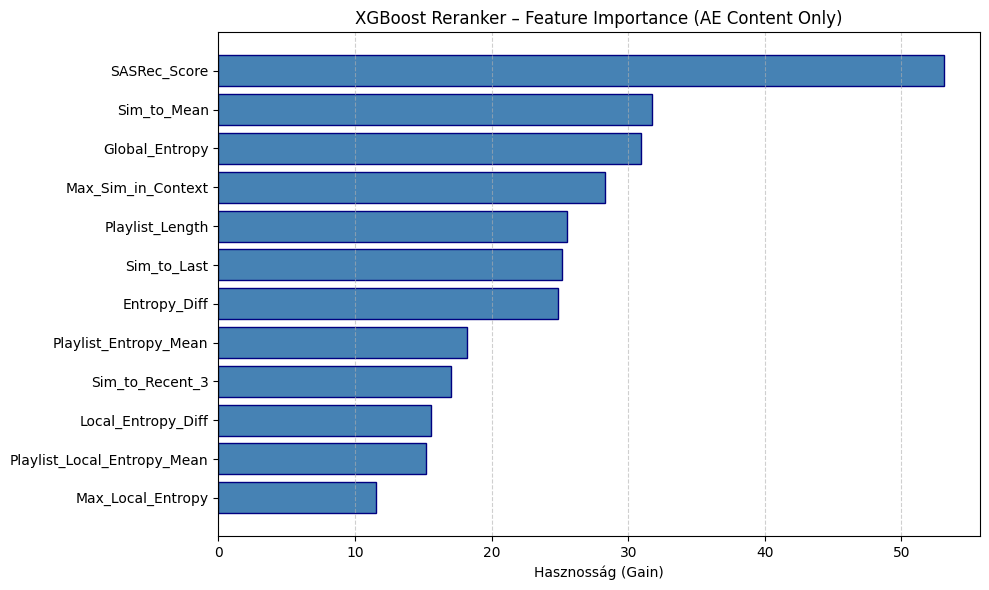


📈 Tanulási görbe...


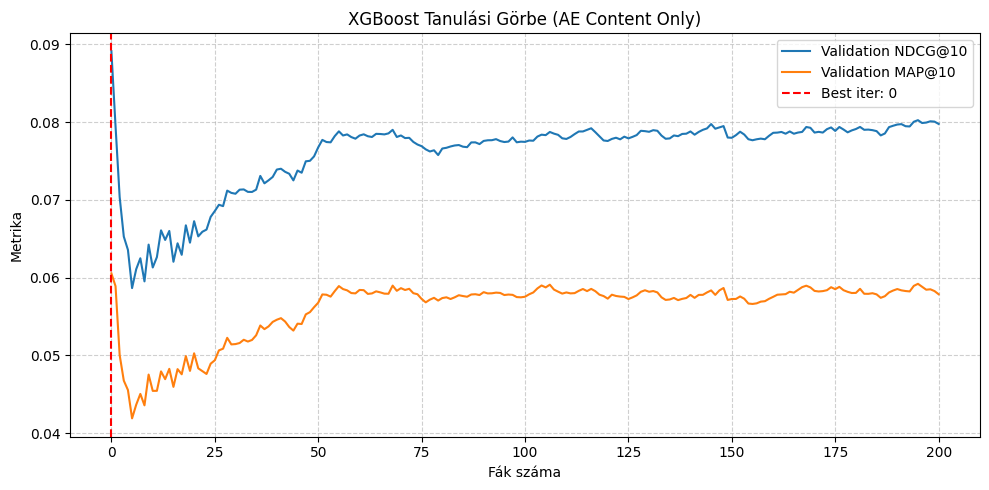


🏆 Legjobb iteráció:  0
🏆 Legjobb NDCG@10:   0.0891
🏆 Legjobb MAP@10:    0.0606


In [2]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgb_train_ae_mel_only_filtered.parquet")
df = df.sort_values("Playlist_ID").reset_index(drop=True)

# Listán belüli shuffle — pozitív ne legyen mindig elöl
shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

print(f"✅ Betöltve: {len(df):,} sor | Pozitív arány: {df['Label'].mean():.4f}")

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA (csak tartalom alapú)
# ==========================================
features = [
    'Playlist_Length',
    'SASRec_Score',           # SASRec dot product (tartalom-tér)
    'Sim_to_Last',            # koszinusz hasonlóság az utolsó dalhoz
    'Sim_to_Mean',            # hasonlóság a lista centroidjához
    'Sim_to_Recent_3',        # hasonlóság az utolsó 3 dalhoz átlagban
    'Max_Sim_in_Context',     # leghasonlóbb kontextus-dal hasonlósága
    'Global_Entropy',         # Markov-entrópia (dal-szintű)
    'Max_Local_Entropy',      # max lokális Markov-entrópia
    'Playlist_Entropy_Mean',       # kontextus átlag entrópiája
    'Playlist_Local_Entropy_Mean', # kontextus max lokális entrópia átlaga
    'Entropy_Diff',           # |jelölt - playlist| globális entrópia különbség
    'Local_Entropy_Diff',     # |jelölt - playlist| lokális entrópia különbség
]

X      = df[features]
y      = df['Label']
groups = df['Playlist_ID']

print(f"📋 Feature-ök ({len(features)} db): {features}")

# ==========================================
# 3. TRAIN-VAL SPLIT (utolsó 5000 lista = validáció)
# ==========================================
total_playlists = groups.max()
train_mask = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_mask],  y[train_mask],  groups[train_mask]
X_val,   y_val,   qid_val   = X[~train_mask], y[~train_mask], groups[~train_mask]

print(f"\n✅ Tanító:     {len(X_train):,} sor ({qid_train.nunique():,} lista)")
print(f"✅ Validációs: {len(X_val):,} sor ({qid_val.nunique():,} lista)")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    tree_method='hist',
    random_state=42,
    eval_metric=['ndcg@10', 'map@10'],
    early_stopping_rounds=200
)

ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)],
    eval_qid=[qid_val],
    verbose=50
)

# ==========================================
# 5. MENTÉS
# ==========================================
MODEL_OUT = "../Models/xgboost_reranker_ae_mel_only.json"
ranker.save_model(MODEL_OUT)
print(f"\n💾 Modell elmentve: {MODEL_OUT}")

# ==========================================
# 6. VIZUALIZÁCIÓ
# ==========================================
print("\n📊 Feature Importance...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], values[::-1], color='steelblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain)")
plt.title("XGBoost Reranker – Feature Importance (AE Content Only)")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n📈 Tanulási görbe...")
results = ranker.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--',
            label=f'Best iter: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe (AE Content Only)')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\n🏆 Legjobb iteráció:  {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10:   {max(results['validation_0']['ndcg@10']):.4f}")
print(f"🏆 Legjobb MAP@10:    {max(results['validation_0']['map@10']):.4f}")

## Teszt tábla

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm.auto import tqdm
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
AE_MATRIX_PATH  = "../Models/ae_vectors_closed_world_mel_only.npy"
VAL_DATA_PATH   = "../Models/test_pids_ae.npy"
WEIGHTS_PATH    = "../Models/best_sasrec_bpr_ae_mel_only.weights.h5"
H5_PATH         = "../Dataset/spotify_dataset_compressed.h5"
OUTPUT_PARQUET  = "../Models/xgb_test_ae_mel_only.parquet"

MAX_LEN    = 50
D_MODEL    = 256
BATCH_SIZE = 256
TOP_K      = 500

# ==========================================
# 2. EMBEDDINGEK ÉS VOCAB BETÖLTÉSE
# ==========================================
print("📂 AE vektorok betöltése...")
ae_weights = np.load(AE_MATRIX_PATH).astype('float32')

# Padding sor hozzáadása (0-s ID = csupa nulla vektor) — ugyanaz mint tanításnál!
padding_row = np.zeros((1, D_MODEL), dtype='float32')
embedding_matrix = np.vstack([padding_row, ae_weights])  # (vocab_size, 256)
vocab_size = embedding_matrix.shape[0]
print(f"✅ Embedding mátrix: {embedding_matrix.shape} | vocab_size: {vocab_size}")

# Az AE encoder L2-normált vektorokat ad ki → dot product = koszinusz hasonlóság.
# Normalizáljuk a kész mátrixot is FAISS-hoz.
embeddings_norm = embedding_matrix.copy()
faiss.normalize_L2(embeddings_norm)

# ==========================================
# 3. HDF5 METAADATOK BETÖLTÉSE (TARTALOM ALAPÚ)
# ==========================================
print("🧮 HDF5 tartalom metaadatok betöltése...")

track_global_entropy    = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)

with h5py.File(H5_PATH, "r") as hf:
    # A zárt világ mapping: HDF5 index + 1 = SASRec ID (pontosan ahogy a mapping szkript csinálja)
    track_uris_hdf5     = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data  = hf["features/markov_entropy_local"][:]

    for hdf5_idx in tqdm(range(len(track_uris_hdf5)), desc="Entropy mapping"):
        sasrec_id = hdf5_idx + 1  # ID = index + 1 (padding miatt)
        if sasrec_id < vocab_size:
            track_global_entropy[sasrec_id]    = entropy_global_data[hdf5_idx][0]
            track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])

print(f"✅ Entropy feltöltve: {(~np.isnan(track_global_entropy)).sum():,} / {vocab_size:,} dal")

# ==========================================
# 4. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec inferencia modell felépítése...")

def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="ae_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL // 8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embedding_matrix)
inference_model.load_weights(WEIGHTS_PATH)
print("✅ Súlyok betöltve!")

# ==========================================
# 5. FAISS INDEX FELÉPÍTÉSE A FINOMHANGOLT EMBEDDINGEKBŐL
# ==========================================
print("🔍 FAISS Index felépítése a tanult embeddingekből...")
learned_embeddings = inference_model.get_layer("ae_embedding").get_weights()[0].astype('float32')
faiss_embeddings   = learned_embeddings.copy()
faiss.normalize_L2(faiss_embeddings)

index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)
print(f"✅ FAISS index: {index.ntotal:,} vektor")

# A normalizált learned embeddinget fogjuk feature számításhoz is használni
# (konzisztens a FAISS kereséssel)
learned_embeddings_norm = faiss_embeddings

# ==========================================
# 6. PLAYLIST-SZINTŰ KONTEXTUS FEATURE-ÖK SZÁMÍTÁSA
#    (Tartalom alapú — nem tartalmaz kollaboratív jelet)
# ==========================================
# Feature-ök magyarázata:
#   Sim_to_Last       — koszinusz hasonlóság az utolsó hallgatott dalhoz
#   Sim_to_Mean       — hasonlóság a lista átlagvektorához
#   Sim_to_Recent_3   — hasonlóság az utolsó 3 dalhoz átlagban
#   Max_Sim_in_Context — a legközelebbi kontextus-dal hasonlósága (top-1)
#   Global_Entropy    — Markov-entrópia (átmeneti sokszínűség a dalban)
#   Max_Local_Entropy — max lokális Markov-entrópia
#   Entropy_Diff      — |jelölt entrópiája − lista átlag entrópiája|
#   Local_Entropy_Diff — max lokális entrópia különbség
#   Playlist_Entropy_Mean — a kontextus dalainak átlag entrópiája
#   Playlist_Local_Entropy_Mean — kontextus max lokális entrópia átlaga
#   SASRec_Score      — dot product a predikált vektorral (FAISS)
#   SASRec_Rank       — sorrendi pozíció a FAISS listában

# ==========================================
# 7. KÖTEGELT TÁBLÁZATGENERÁLÁS
# ==========================================
print("🚀 Táblázat generálása...")

val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
# Nulla paddingok eltávolítása (ha van)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)
print(f"📊 Validációs listák: {len(val_playlists):,}")

dataset_rows       = []
global_playlist_id = 0
writer             = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []

    for pl in batch_lists:
        if len(pl) < 2:
            continue
        targets.append(pl[-1])           # utolsó dal = target (leave-one-out)
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    if not batch_padded:
        continue

    # SASRec predikció
    pred_states        = inference_model.predict_on_batch(np.array(batch_padded))
    query_vectors      = pred_states[:, -1, :].astype('float32')  # utolsó pozíció
    faiss.normalize_L2(query_vectors)
    raw_scores, raw_indices = index.search(query_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(valid_contexts)):
        context      = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        context_set  = set(context)

        # --- Playlist-szintű feature-ök (minden jelöltre azonos) ---
        ctx_vecs = learned_embeddings_norm[list(context)]  # (N, D)

        last_vec          = learned_embeddings_norm[context[-1]]
        playlist_mean_vec = np.mean(ctx_vecs, axis=0)
        norm = np.linalg.norm(playlist_mean_vec)
        playlist_mean_vec = playlist_mean_vec / (norm + 1e-8)

        recent_3     = context[-3:]
        recent_3_vecs = learned_embeddings_norm[recent_3]  # (3, D)

        ctx_entropies       = [track_global_entropy[t] for t in context
                               if not np.isnan(track_global_entropy[t])]
        ctx_local_entropies = [track_max_local_entropy[t] for t in context
                               if not np.isnan(track_max_local_entropy[t])]

        playlist_entropy_mean       = float(np.mean(ctx_entropies))       if ctx_entropies       else 0.0
        playlist_local_entropy_mean = float(np.mean(ctx_local_entropies)) if ctx_local_entropies else 0.0

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context_set or cand_id == 0:
                continue
            if len(pos_samples) + len(neg_samples) >= TOP_K:
                break

            is_target  = 1 if cand_id == actual_target else 0
            cand_vec   = learned_embeddings_norm[cand_id]
            cand_g_ent = track_global_entropy[cand_id]
            cand_l_ent = track_max_local_entropy[cand_id]

            # --- Jelölt-szintű tartalom feature-ök ---
            sim_to_last     = float(np.dot(last_vec, cand_vec))
            sim_to_mean     = float(np.dot(playlist_mean_vec, cand_vec))
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))
            max_sim_in_ctx  = float(np.max(ctx_vecs @ cand_vec))

            entropy_diff       = float(abs(cand_g_ent - playlist_entropy_mean)) \
                                 if not np.isnan(cand_g_ent) else -1.0
            local_entropy_diff = float(abs(cand_l_ent - playlist_local_entropy_mean)) \
                                 if not np.isnan(cand_l_ent) else -1.0

            row = {
                # --- Azonosítók ---
                "Playlist_ID":    global_playlist_id,
                "Candidate_ID":   int(cand_id),
                "Playlist_Length": len(context),
                # --- SASRec rangsor ---
                "SASRec_Rank":  current_rank,
                "SASRec_Score": float(score),
                # --- Hasonlóság feature-ök (tartalom) ---
                "Sim_to_Last":       sim_to_last,
                "Sim_to_Mean":       sim_to_mean,
                "Sim_to_Recent_3":   sim_to_recent_3,
                "Max_Sim_in_Context": max_sim_in_ctx,
                # --- Entrópia feature-ök (tartalom) ---
                "Global_Entropy":           float(cand_g_ent) if not np.isnan(cand_g_ent) else -1.0,
                "Max_Local_Entropy":        float(cand_l_ent) if not np.isnan(cand_l_ent) else -1.0,
                "Playlist_Entropy_Mean":       playlist_entropy_mean,
                "Playlist_Local_Entropy_Mean": playlist_local_entropy_mean,
                "Entropy_Diff":       entropy_diff,
                "Local_Entropy_Diff": local_entropy_diff,
                # --- Cél ---
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH: 500k soronként írunk lemezre ---
    if len(dataset_rows) >= 500_000:
        df_chunk = pd.DataFrame(dataset_rows)
        table    = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 8. MARADÉK MENTÉS ÉS FÁJL LEZÁRÁS
# ==========================================
print("💾 Maradék sorok mentése...")
if dataset_rows:
    df_chunk = pd.DataFrame(dataset_rows)
    table    = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 9. SZŰRÉS: csak azok a listák maradnak, ahol a target megjelent a TOP_K-ban
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)

lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered    = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)

filtered_path  = OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet')
df_filtered.to_parquet(filtered_path, index=False)

print(f"\n🎉 KÉSZ!")
print(f"   Összes sor:        {len(df):,}")
print(f"   Szűrt sor:         {len(df_filtered):,}")
print(f"   Listák targettel:  {len(lists_with_pos):,} / {global_playlist_id:,}")
print(f"   Pozitív arány:     {df_filtered['Label'].mean():.4f}")
print(f"\n   Feature-ök: {[c for c in df_filtered.columns if c not in ['Playlist_ID','Candidate_ID','Label']]}")

del df, df_filtered
gc.collect()

📂 AE vektorok betöltése...
✅ Embedding mátrix: (27053, 256) | vocab_size: 27053
🧮 HDF5 tartalom metaadatok betöltése...


Entropy mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

✅ Entropy feltöltve: 27,052 / 27,053 dal
🏗️ SASRec inferencia modell felépítése...
✅ Súlyok betöltve!
🔍 FAISS Index felépítése a tanult embeddingekből...
✅ FAISS index: 27,053 vektor
🚀 Táblázat generálása...
📊 Validációs listák: 88,316


SASRec predikciók:   0%|          | 0/345 [00:00<?, ?it/s]

💾 Maradék sorok mentése...
🧹 Pozitív nélküli listák szűrése...

🎉 KÉSZ!
   Összes sor:        43,976,504
   Szűrt sor:         28,254,886
   Listák targettel:  56,761 / 88,316
   Pozitív arány:     0.0020

   Feature-ök: ['Playlist_Length', 'SASRec_Rank', 'SASRec_Score', 'Sim_to_Last', 'Sim_to_Mean', 'Sim_to_Recent_3', 'Max_Sim_in_Context', 'Global_Entropy', 'Max_Local_Entropy', 'Playlist_Entropy_Mean', 'Playlist_Local_Entropy_Mean', 'Entropy_Diff', 'Local_Entropy_Diff']


17

## Kiértékelés

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb

df_test = pd.read_parquet("../Models/xgb_test_ae_mel_only.parquet")

features = [
    'Playlist_Length',
    'SASRec_Score',           # SASRec dot product (tartalom-tér)
    'Sim_to_Last',            # koszinusz hasonlóság az utolsó dalhoz
    'Sim_to_Mean',            # hasonlóság a lista centroidjához
    'Sim_to_Recent_3',        # hasonlóság az utolsó 3 dalhoz átlagban
    'Max_Sim_in_Context',     # leghasonlóbb kontextus-dal hasonlósága
    'Global_Entropy',         # Markov-entrópia (dal-szintű)
    'Max_Local_Entropy',      # max lokális Markov-entrópia
    'Playlist_Entropy_Mean',       # kontextus átlag entrópiája
    'Playlist_Local_Entropy_Mean', # kontextus max lokális entrópia átlaga
    'Entropy_Diff',           # |jelölt - playlist| globális entrópia különbség
    'Local_Entropy_Diff',     # |jelölt - playlist| lokális entrópia különbség
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_ae_mel_only.json")

df_test['XGB_Score'] = ranker.predict(df_test[features])
df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

def calculate_metrics(df, rank_col, k_list):
    hits_df = df[df['Label'] == 1].copy()
    pos_ranks = hits_df[rank_col].values
    total_queries = df['Playlist_ID'].nunique()
    
    results = []
    for k in k_list:
        hr    = (pos_ranks <= k).sum() / total_queries
        ndcg  = np.sum([1/np.log2(r+1) if r <= k else 0 for r in pos_ranks]) / total_queries
        map_k = np.sum([1/r if r <= k else 0 for r in pos_ranks]) / total_queries
        results.append({'k': k, 'HR': hr, 'NDCG': ndcg, 'MAP': map_k})
    
    def get_click(r):
        if r > 500 or pd.isna(r): return 51
        return (int(r) - 1) // 10
    avg_clicks = hits_df[rank_col].apply(get_click).sum()
    missing = total_queries - len(hits_df)
    avg_clicks = (avg_clicks + missing * 51) / total_queries
    
    return pd.DataFrame(results), avg_clicks

K_VALUES = [1, 5, 10, 20, 50, 100, 200, 500]
sas_m, sas_c = calculate_metrics(df_test, 'SASRec_Rank', K_VALUES)
xgb_m, xgb_c = calculate_metrics(df_test, 'XGB_Rank',   K_VALUES)

summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')
for m in ['HR', 'NDCG', 'MAP']:
    summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

print("\n" + "="*70)
print("🏆 EREDMÉNYEK")
print("="*70)
pd.options.display.float_format = '{:.4f}'.format
cols = [c for m in ['HR','NDCG','MAP'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
print(summary[cols].T.to_string())
print(f"\n🖱️ Clicks SASRec:  {sas_c:.4f}")
print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


🏆 EREDMÉNYEK
k              1       5       10      20      50      100     200     500
HR_SAS      0.0127  0.0583  0.0993  0.1566  0.2664  0.3693  0.4855  0.6427
HR_XGB      0.0276  0.0966  0.1539  0.2321  0.3683  0.4824  0.5833  0.6427
HR_imp%   118.0680 65.5989 54.9994 48.2641 38.2363 30.6291 20.1357  0.0000
NDCG_SAS    0.0127  0.0354  0.0485  0.0629  0.0846  0.1012  0.1175  0.1364
NDCG_XGB    0.0276  0.0622  0.0806  0.1002  0.1272  0.1458  0.1599  0.1672
NDCG_imp% 118.0680 75.7625 66.1420 59.3454 50.4005 43.9586 36.1072 22.5619
MAP_SAS     0.0127  0.0279  0.0332  0.0372  0.0406  0.0420  0.0429  0.0434
MAP_XGB     0.0276  0.0509  0.0585  0.0638  0.0681  0.0697  0.0705  0.0707
MAP_imp%  118.0680 82.6353 75.8779 71.6974 67.8112 65.8849 64.3894 62.9413

🖱️ Clicks SASRec:  25.9726
🖱️ Clicks XGBoost: 22.4980
🚀 Clicks javulás: -13.38%


# Normális

📂 Parquet fájl betöltése...
✅ Betöltve: 27,745,946 sor | Pozitív arány: 0.0020
📋 Feature-ök (10 db): ['Playlist_Length', 'SASRec_Score', 'Sim_to_Last', 'Sim_to_Mean', 'Sim_to_Recent_3', 'Max_Sim_in_Context', 'Global_Entropy', 'Max_Local_Entropy', 'Entropy_Diff', 'Local_Entropy_Diff']

✅ Tanító:     26,181,306 sor (52,582 lista)
✅ Validációs: 1,564,640 sor (3,143 lista)

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.08097	validation_0-map@10:0.05733
[50]	validation_0-ndcg@10:0.07541	validation_0-map@10:0.05490
[100]	validation_0-ndcg@10:0.08033	validation_0-map@10:0.05879
[150]	validation_0-ndcg@10:0.08158	validation_0-map@10:0.05968
[200]	validation_0-ndcg@10:0.08202	validation_0-map@10:0.05966
[250]	validation_0-ndcg@10:0.08514	validation_0-map@10:0.06192
[300]	validation_0-ndcg@10:0.08528	validation_0-map@10:0.06127
[350]	validation_0-ndcg@10:0.08503	validation_0-map@10:0.06177
[400]	validation_0-ndcg@10:0.08451	validation_0-map@10:0.06141
[450]	validation_0-ndcg@10:0.0851

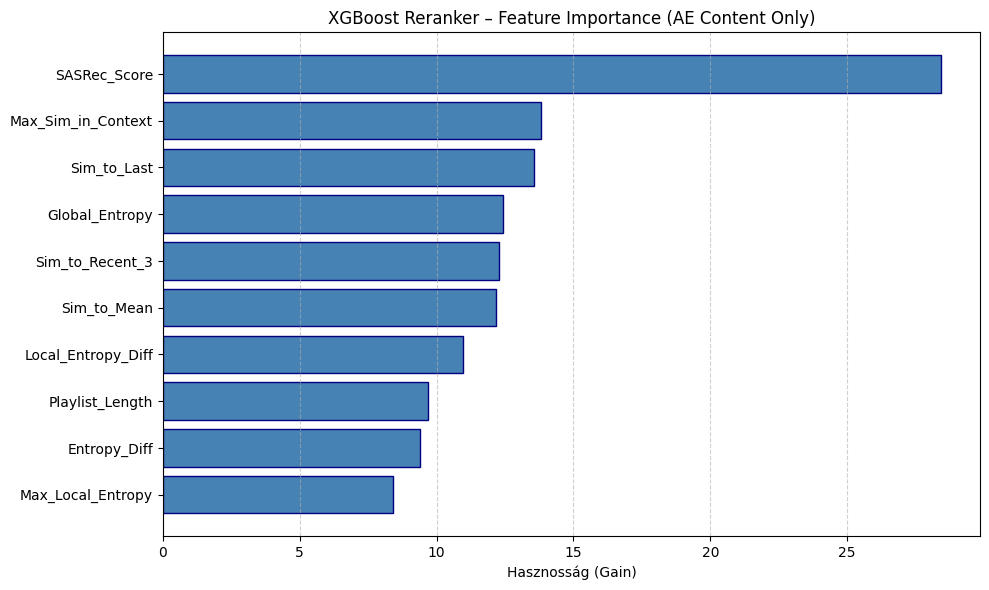


📈 Tanulási görbe...


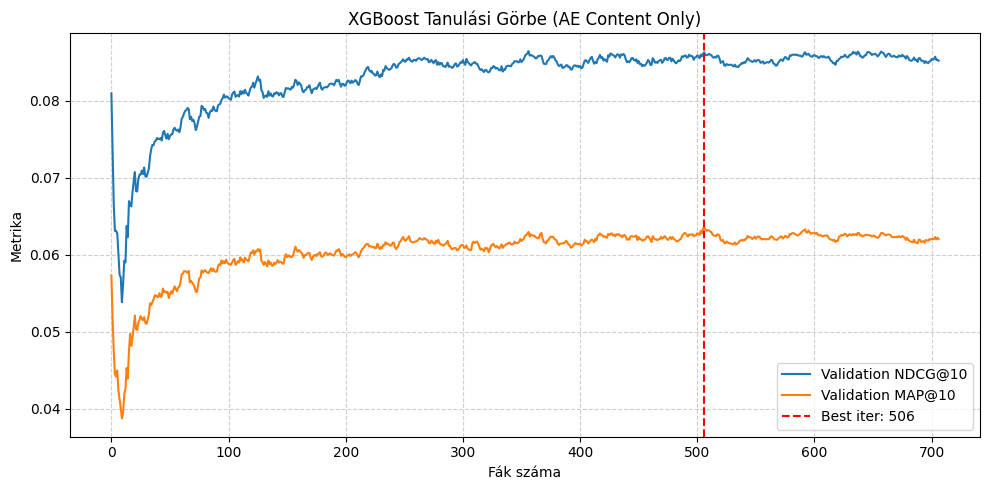


🏆 Legjobb iteráció:  506
🏆 Legjobb NDCG@10:   0.0864
🏆 Legjobb MAP@10:    0.0635


In [1]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgb_train_ae_mel_only_filtered.parquet")
df = df.sort_values("Playlist_ID").reset_index(drop=True)

# Listán belüli shuffle — pozitív ne legyen mindig elöl
shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

print(f"✅ Betöltve: {len(df):,} sor | Pozitív arány: {df['Label'].mean():.4f}")

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA (csak tartalom alapú)
# ==========================================
features = [
    'Playlist_Length',
    'SASRec_Score',           # SASRec dot product (tartalom-tér)
    'Sim_to_Last',            # koszinusz hasonlóság az utolsó dalhoz
    'Sim_to_Mean',            # hasonlóság a lista centroidjához
    'Sim_to_Recent_3',        # hasonlóság az utolsó 3 dalhoz átlagban
    'Max_Sim_in_Context',     # leghasonlóbb kontextus-dal hasonlósága
    'Global_Entropy',         # Markov-entrópia (dal-szintű)
    'Max_Local_Entropy',      # max lokális Markov-entrópia
    # 'Playlist_Entropy_Mean',       # kontextus átlag entrópiája
    # 'Playlist_Local_Entropy_Mean', # kontextus max lokális entrópia átlaga
    'Entropy_Diff',           # |jelölt - playlist| globális entrópia különbség
    'Local_Entropy_Diff',     # |jelölt - playlist| lokális entrópia különbség
]

X      = df[features]
y      = df['Label']
groups = df['Playlist_ID']

print(f"📋 Feature-ök ({len(features)} db): {features}")

# ==========================================
# 3. TRAIN-VAL SPLIT (utolsó 5000 lista = validáció)
# ==========================================
total_playlists = groups.max()
train_mask = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_mask],  y[train_mask],  groups[train_mask]
X_val,   y_val,   qid_val   = X[~train_mask], y[~train_mask], groups[~train_mask]

print(f"\n✅ Tanító:     {len(X_train):,} sor ({qid_train.nunique():,} lista)")
print(f"✅ Validációs: {len(X_val):,} sor ({qid_val.nunique():,} lista)")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    tree_method='hist',
    random_state=42,
    eval_metric=['ndcg@10', 'map@10'],
    early_stopping_rounds=200
)

ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)],
    eval_qid=[qid_val],
    verbose=50
)

# ==========================================
# 5. MENTÉS
# ==========================================
MODEL_OUT = "../Models/xgboost_reranker_ae_mel_only_v2.json"
ranker.save_model(MODEL_OUT)
print(f"\n💾 Modell elmentve: {MODEL_OUT}")

# ==========================================
# 6. VIZUALIZÁCIÓ
# ==========================================
print("\n📊 Feature Importance...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], values[::-1], color='steelblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain)")
plt.title("XGBoost Reranker – Feature Importance (AE Content Only)")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n📈 Tanulási görbe...")
results = ranker.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--',
            label=f'Best iter: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe (AE Content Only)')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\n🏆 Legjobb iteráció:  {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10:   {max(results['validation_0']['ndcg@10']):.4f}")
print(f"🏆 Legjobb MAP@10:    {max(results['validation_0']['map@10']):.4f}")

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb

df_test = pd.read_parquet("../Models/xgb_test_ae_mel_only.parquet")

features = [
    'Playlist_Length',
    'SASRec_Score',           # SASRec dot product (tartalom-tér)
    'Sim_to_Last',            # koszinusz hasonlóság az utolsó dalhoz
    'Sim_to_Mean',            # hasonlóság a lista centroidjához
    'Sim_to_Recent_3',        # hasonlóság az utolsó 3 dalhoz átlagban
    'Max_Sim_in_Context',     # leghasonlóbb kontextus-dal hasonlósága
    'Global_Entropy',         # Markov-entrópia (dal-szintű)
    'Max_Local_Entropy',      # max lokális Markov-entrópia
    'Entropy_Diff',           # |jelölt - playlist| globális entrópia különbség
    'Local_Entropy_Diff',     # |jelölt - playlist| lokális entrópia különbség
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_ae_mel_only_v2.json")

df_test['XGB_Score'] = ranker.predict(df_test[features])
df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

def calculate_metrics(df, rank_col, k_list):
    hits_df = df[df['Label'] == 1].copy()
    pos_ranks = hits_df[rank_col].values
    total_queries = df['Playlist_ID'].nunique()
    
    results = []
    for k in k_list:
        hr    = (pos_ranks <= k).sum() / total_queries
        ndcg  = np.sum([1/np.log2(r+1) if r <= k else 0 for r in pos_ranks]) / total_queries
        map_k = np.sum([1/r if r <= k else 0 for r in pos_ranks]) / total_queries
        results.append({'k': k, 'HR': hr, 'NDCG': ndcg, 'MAP': map_k})
    
    def get_click(r):
        if r > 500 or pd.isna(r): return 51
        return (int(r) - 1) // 10
    avg_clicks = hits_df[rank_col].apply(get_click).sum()
    missing = total_queries - len(hits_df)
    avg_clicks = (avg_clicks + missing * 51) / total_queries
    
    return pd.DataFrame(results), avg_clicks

K_VALUES = [1, 5, 10, 20, 50, 100, 200, 500]
sas_m, sas_c = calculate_metrics(df_test, 'SASRec_Rank', K_VALUES)
xgb_m, xgb_c = calculate_metrics(df_test, 'XGB_Rank',   K_VALUES)

summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')
for m in ['HR', 'NDCG', 'MAP']:
    summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

print("\n" + "="*70)
print("🏆 EREDMÉNYEK")
print("="*70)
pd.options.display.float_format = '{:.4f}'.format
cols = [c for m in ['HR','NDCG','MAP'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
print(summary[cols].T.to_string())
print(f"\n🖱️ Clicks SASRec:  {sas_c:.4f}")
print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


🏆 EREDMÉNYEK
k             1       5       10      20      50      100     200     500
HR_SAS     0.0127  0.0583  0.0993  0.1566  0.2664  0.3693  0.4855  0.6427
HR_XGB     0.0180  0.0633  0.1016  0.1580  0.2633  0.3658  0.4803  0.6427
HR_imp%   42.3971  8.4644  2.3372  0.9475 -1.1645 -0.9566 -1.0705  0.0000
NDCG_SAS   0.0127  0.0354  0.0485  0.0629  0.0846  0.1012  0.1175  0.1364
NDCG_XGB   0.0180  0.0406  0.0529  0.0671  0.0879  0.1045  0.1205  0.1400
NDCG_imp% 42.3971 14.7624  9.0633  6.6579  3.8887  3.1917  2.5565  2.6400
MAP_SAS    0.0127  0.0279  0.0332  0.0372  0.0406  0.0420  0.0429  0.0434
MAP_XGB    0.0180  0.0332  0.0382  0.0421  0.0454  0.0468  0.0476  0.0482
MAP_imp%  42.3971 19.0381 14.9804 13.2559 11.7926 11.3794 11.1345 11.0309

🖱️ Clicks SASRec:  25.9726
🖱️ Clicks XGBoost: 26.1343
🚀 Clicks javulás: 0.62%


# Entrópia nélkül

📂 Parquet fájl betöltése...
✅ Betöltve: 27,745,946 sor | Pozitív arány: 0.0020
📋 Feature-ök (6 db): ['Playlist_Length', 'SASRec_Score', 'Sim_to_Last', 'Sim_to_Mean', 'Sim_to_Recent_3', 'Max_Sim_in_Context']

✅ Tanító:     26,181,306 sor (52,582 lista)
✅ Validációs: 1,564,640 sor (3,143 lista)

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.03001	validation_0-map@10:0.02161
[50]	validation_0-ndcg@10:0.05951	validation_0-map@10:0.04214
[100]	validation_0-ndcg@10:0.06554	validation_0-map@10:0.04753
[150]	validation_0-ndcg@10:0.06962	validation_0-map@10:0.05056
[200]	validation_0-ndcg@10:0.07117	validation_0-map@10:0.05188
[250]	validation_0-ndcg@10:0.07240	validation_0-map@10:0.05229
[300]	validation_0-ndcg@10:0.07384	validation_0-map@10:0.05320
[350]	validation_0-ndcg@10:0.07597	validation_0-map@10:0.05543
[400]	validation_0-ndcg@10:0.07562	validation_0-map@10:0.05444
[450]	validation_0-ndcg@10:0.07535	validation_0-map@10:0.05436
[500]	validation_0-ndcg@10:0.07480	validation_0-

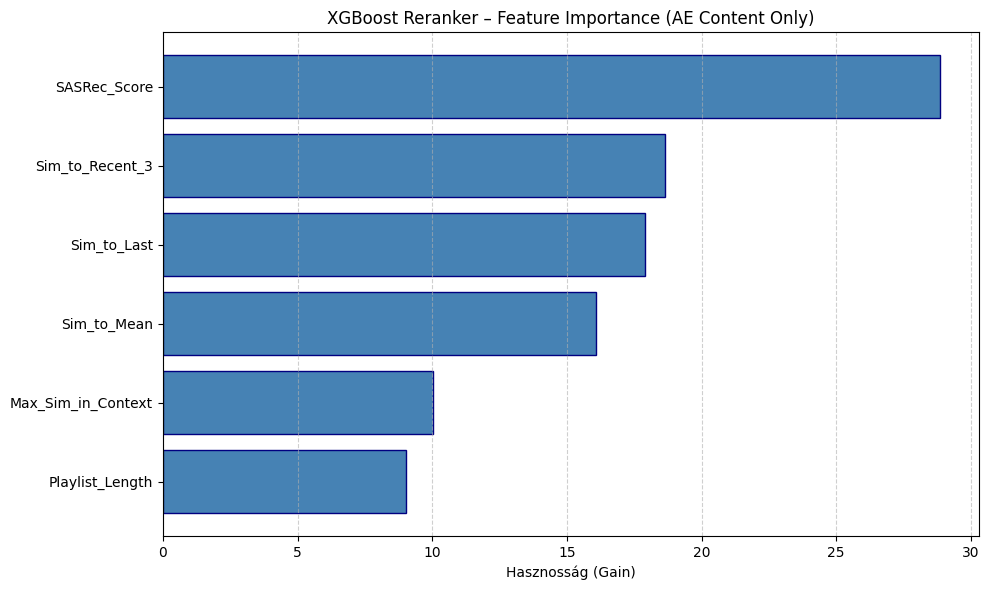


📈 Tanulási görbe...


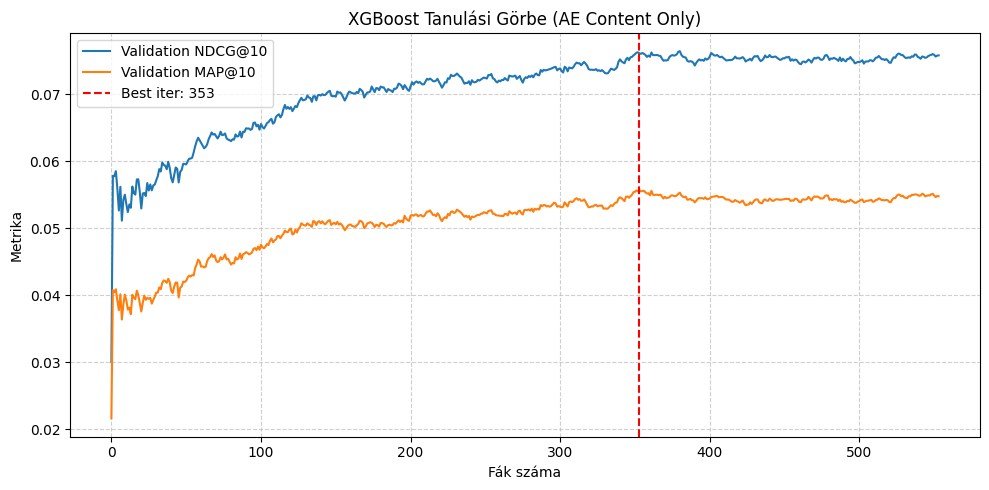


🏆 Legjobb iteráció:  353
🏆 Legjobb NDCG@10:   0.0764
🏆 Legjobb MAP@10:    0.0557


In [3]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgb_train_ae_mel_only_filtered.parquet")
df = df.sort_values("Playlist_ID").reset_index(drop=True)

# Listán belüli shuffle — pozitív ne legyen mindig elöl
shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

print(f"✅ Betöltve: {len(df):,} sor | Pozitív arány: {df['Label'].mean():.4f}")

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA (csak tartalom alapú)
# ==========================================
features = [
    'Playlist_Length',
    'SASRec_Score',           # SASRec dot product (tartalom-tér)
    'Sim_to_Last',            # koszinusz hasonlóság az utolsó dalhoz
    'Sim_to_Mean',            # hasonlóság a lista centroidjához
    'Sim_to_Recent_3',        # hasonlóság az utolsó 3 dalhoz átlagban
    'Max_Sim_in_Context',     # leghasonlóbb kontextus-dal hasonlósága
    # 'Global_Entropy',         # Markov-entrópia (dal-szintű)
    # 'Max_Local_Entropy',      # max lokális Markov-entrópia
    # 'Playlist_Entropy_Mean',       # kontextus átlag entrópiája
    # 'Playlist_Local_Entropy_Mean', # kontextus max lokális entrópia átlaga
    # 'Entropy_Diff',           # |jelölt - playlist| globális entrópia különbség
    # 'Local_Entropy_Diff',     # |jelölt - playlist| lokális entrópia különbség
]

X      = df[features]
y      = df['Label']
groups = df['Playlist_ID']

print(f"📋 Feature-ök ({len(features)} db): {features}")

# ==========================================
# 3. TRAIN-VAL SPLIT (utolsó 5000 lista = validáció)
# ==========================================
total_playlists = groups.max()
train_mask = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_mask],  y[train_mask],  groups[train_mask]
X_val,   y_val,   qid_val   = X[~train_mask], y[~train_mask], groups[~train_mask]

print(f"\n✅ Tanító:     {len(X_train):,} sor ({qid_train.nunique():,} lista)")
print(f"✅ Validációs: {len(X_val):,} sor ({qid_val.nunique():,} lista)")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    tree_method='hist',
    random_state=42,
    eval_metric=['ndcg@10', 'map@10'],
    early_stopping_rounds=200
)

ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)],
    eval_qid=[qid_val],
    verbose=50
)

# ==========================================
# 5. MENTÉS
# ==========================================
MODEL_OUT = "../Models/xgboost_reranker_ae_mel_only_v3.json"
ranker.save_model(MODEL_OUT)
print(f"\n💾 Modell elmentve: {MODEL_OUT}")

# ==========================================
# 6. VIZUALIZÁCIÓ
# ==========================================
print("\n📊 Feature Importance...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], values[::-1], color='steelblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain)")
plt.title("XGBoost Reranker – Feature Importance (AE Content Only)")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n📈 Tanulási görbe...")
results = ranker.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--',
            label=f'Best iter: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe (AE Content Only)')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\n🏆 Legjobb iteráció:  {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10:   {max(results['validation_0']['ndcg@10']):.4f}")
print(f"🏆 Legjobb MAP@10:    {max(results['validation_0']['map@10']):.4f}")

In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb

df_test = pd.read_parquet("../Models/xgb_test_ae_mel_only.parquet")

features = [
    'Playlist_Length',
    'SASRec_Score',           # SASRec dot product (tartalom-tér)
    'Sim_to_Last',            # koszinusz hasonlóság az utolsó dalhoz
    'Sim_to_Mean',            # hasonlóság a lista centroidjához
    'Sim_to_Recent_3',        # hasonlóság az utolsó 3 dalhoz átlagban
    'Max_Sim_in_Context',     # leghasonlóbb kontextus-dal hasonlósága
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_ae_mel_only_v3.json")

df_test['XGB_Score'] = ranker.predict(df_test[features])
df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

def calculate_metrics(df, rank_col, k_list):
    hits_df = df[df['Label'] == 1].copy()
    pos_ranks = hits_df[rank_col].values
    total_queries = df['Playlist_ID'].nunique()
    
    results = []
    for k in k_list:
        hr    = (pos_ranks <= k).sum() / total_queries
        ndcg  = np.sum([1/np.log2(r+1) if r <= k else 0 for r in pos_ranks]) / total_queries
        map_k = np.sum([1/r if r <= k else 0 for r in pos_ranks]) / total_queries
        results.append({'k': k, 'HR': hr, 'NDCG': ndcg, 'MAP': map_k})
    
    def get_click(r):
        if r > 500 or pd.isna(r): return 51
        return (int(r) - 1) // 10
    avg_clicks = hits_df[rank_col].apply(get_click).sum()
    missing = total_queries - len(hits_df)
    avg_clicks = (avg_clicks + missing * 51) / total_queries
    
    return pd.DataFrame(results), avg_clicks

K_VALUES = [1, 5, 10, 20, 50, 100, 200, 500]
sas_m, sas_c = calculate_metrics(df_test, 'SASRec_Rank', K_VALUES)
xgb_m, xgb_c = calculate_metrics(df_test, 'XGB_Rank',   K_VALUES)

summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')
for m in ['HR', 'NDCG', 'MAP']:
    summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

print("\n" + "="*70)
print("🏆 EREDMÉNYEK")
print("="*70)
pd.options.display.float_format = '{:.4f}'.format
cols = [c for m in ['HR','NDCG','MAP'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
print(summary[cols].T.to_string())
print(f"\n🖱️ Clicks SASRec:  {sas_c:.4f}")
print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


🏆 EREDMÉNYEK
k             1       5       10      20      50      100     200    500
HR_SAS     0.0127  0.0583  0.0993  0.1566  0.2664  0.3693  0.4855 0.6427
HR_XGB     0.0157  0.0575  0.0960  0.1512  0.2573  0.3596  0.4749 0.6427
HR_imp%   23.8819 -1.3590 -3.3634 -3.3922 -3.4212 -2.6275 -2.1922 0.0000
NDCG_SAS   0.0127  0.0354  0.0485  0.0629  0.0846  0.1012  0.1175 0.1364
NDCG_XGB   0.0157  0.0365  0.0488  0.0627  0.0837  0.1002  0.1163 0.1365
NDCG_imp% 23.8819  3.1959  0.5989 -0.3084 -1.1091 -1.0164 -0.9754 0.0674
MAP_SAS    0.0127  0.0279  0.0332  0.0372  0.0406  0.0420  0.0429 0.0434
MAP_XGB    0.0157  0.0296  0.0347  0.0384  0.0417  0.0432  0.0440 0.0446
MAP_imp%  23.8819  6.3043  4.2183  3.4347  2.8606  2.7454  2.6854 2.7176

🖱️ Clicks SASRec:  25.9726
🖱️ Clicks XGBoost: 26.3479
🚀 Clicks javulás: 1.45%
